In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn import set_config

### 1. Data Loading and Target Creation

In [30]:
# Load the dataset
df = pd.read_csv('data.csv')

In [31]:
df.head()

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,Institutional,NaN,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor


In [32]:
# Create the binary target variable: 1 for 'risky' (anything other than 'monitor'), 0 for 'monitor'
df['is_risky'] = df['risk_labels'].apply(lambda x: 0 if x == 'monitor' else 1)

In [33]:
# Define feature matrix X and target vector y
X = df.drop(columns=['is_risky'])
y = df['is_risky']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (2963, 17)
Shape of y: (2963,)


### 2. Data Splitting (Stratified to handle class imbalance)

In [34]:
# Stratify the split (80% train, 20% test) to maintain the proportion of classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("\nDistribution of 'is_risky' in y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of 'is_risky' in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (2370, 17)
Shape of X_test: (593, 17)
Shape of y_train: (2370,)
Shape of y_test: (593,)

Distribution of 'is_risky' in y_train:
is_risky
0    0.672152
1    0.327848
Name: proportion, dtype: float64

Distribution of 'is_risky' in y_test:
is_risky
0    0.671164
1    0.328836
Name: proportion, dtype: float64


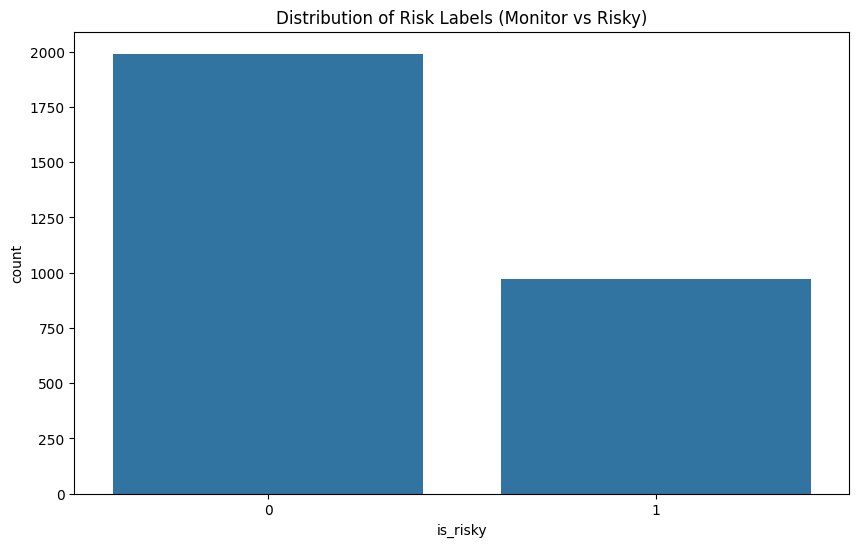

In [35]:
# Visualize class distribution in y_train and y_test
plt.figure(figsize=(10, 6))
sns.countplot(x='is_risky', data=df)
plt.title('Distribution of Risk Labels (Monitor vs Risky)')
plt.show()


### 3. Define Feature Types

In [52]:
# Numerical features that require imputation and scaling
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()


In [51]:
# Categorical features that require imputation and one-hot encoding
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


In [53]:
dropped_explicitly = ['segment_id', 'risk_labels']

# Remove explicitly dropped features from categorical_features if they were included by select_dtypes
categorical_features = [f for f in categorical_features if f not in dropped_explicitly]

print("Numerical features defined:", numerical_features)
print("Categorical features defined:", categorical_features)
print("Features to be explicitly dropped:", dropped_explicitly)

Numerical features defined: ['latitude', 'longitude', 'elevation_m', 'drainage_density_km_per_km2', 'storm_drain_proximity_m', 'historical_rainfall_intensity_mm_hr', 'return_period_years']
Categorical features defined: ['city_name', 'admin_ward', 'catchment_id', 'dem_source', 'land_use', 'soil_group', 'storm_drain_type', 'rainfall_source']
Features to be explicitly dropped: ['segment_id', 'risk_labels']


### 4. Define Preprocessing Steps using Pipelines

In [54]:
# Pipeline for Numerical Features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [55]:
#Pipeline for Categorical Features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

### 5. Combine Preprocessors with ColumnTransformer

In [56]:
all_processed_features = numerical_features + categorical_features

In [57]:
# This applies the correct transformer to the correct columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

### 6. Create the Full Machine Learning Pipeline

In [58]:
# Chain the preprocessing (preprocessor) and the final estimator (classifier)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

### 7. Fit and Train the Model

In [59]:
model_pipeline.fit(X_train, y_train)
print("Full machine learning pipeline created and fitted to training data.")
display(model_pipeline)

Full machine learning pipeline created and fitted to training data.


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'elevation_m',
                                                   'drainage_density_km_per_km2',
                                                   'storm_drain_proximity_m',
                                                   'historical_rainfall_intensity_mm_hr',
                                                   'return_period_years']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city_name', 'admin_ward',
                                                   'catchment_id', 'dem_source',
                                                   'land_use', 'soil_group',
                                                   'storm_drain_type',
                                                   'rainfall_source'])])),
                ('classifier', LogisticRegression(random_state=42))])

### 8. Hyperparameter tuning using GridSearchCV

In [60]:
param_grid = {
    'classifier__C': [0.1, 1, 10],  # Regularization strength for Logistic Regression
    'classifier__solver': ['lbfgs', 'liblinear'],  # Solvers to use for optimization
    'classifier__max_iter': [100, 200]  # Number of iterations
}

In [61]:
# Set up GridSearchCV with cross-validation
grid_search = GridSearchCV(
    model_pipeline,  # The pipeline to tune
    param_grid,  # The parameter grid to search
    cv=5,  # Cross-validation folds
    scoring='accuracy',  # The evaluation metric (accuracy here)
    n_jobs=-1,  # Use all CPU cores
    verbose=1  # Show progress
)

In [62]:
# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters found: {'classifier__C': 0.1, 'classifier__max_iter': 100, 'classifier__solver': 'lbfgs'}
Best cross-validation score: 0.8215


### 9. Model Evaluation

In [63]:
# Use the best estimator found by GridSearchCV to predict on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [64]:
# Print evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Monitor (0)', 'Risky (1)'])

print(f"Model Accuracy on Test Set: {accuracy:.4f}")
print("\nClassification Report:\n")
print(report)

Model Accuracy on Test Set: 0.7926

Classification Report:

              precision    recall  f1-score   support

 Monitor (0)       0.86      0.83      0.84       398
   Risky (1)       0.67      0.72      0.70       195

    accuracy                           0.79       593
   macro avg       0.77      0.77      0.77       593
weighted avg       0.80      0.79      0.79       593



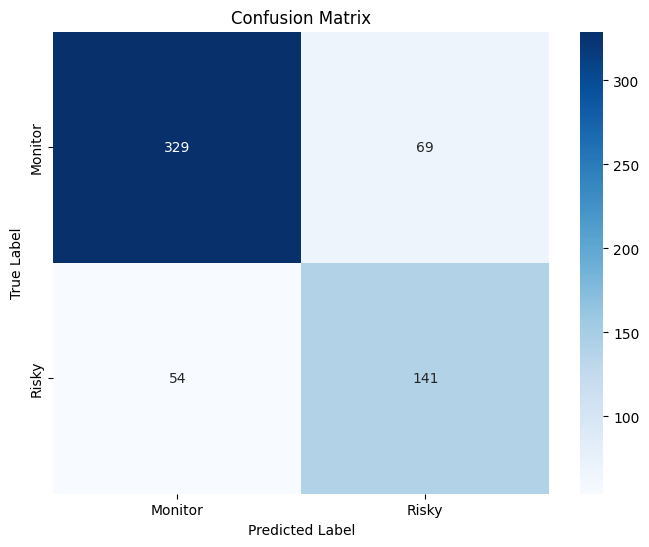

In [65]:
# 15. Visualize the Confusion Matrix (for better insight into model performance)
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Monitor', 'Risky'], yticklabels=['Monitor', 'Risky'])
plt.title("Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()